<a href="https://colab.research.google.com/github/1816x/Algoritmos-Aprendizaje-Automatico/blob/main/Actividad%202%20ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 2: Modelado predictivo con regresión

## Información del dataset

- **Nombre:** Student Performance Factors Dataset
- **Autor:** Mosap Abdel-Ghany
- **Año:** 2025
- **Fuente:** Kaggle
- **Liga:** https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset
- **Fecha de consulta:** 24 de agosto de 2026

## Contexto

El dataset contiene características académicas, personales, familiares y escolares que pueden influir en el desempeño de los estudiantes.

Cada registro representa a un estudiante. La variable objetivo será **Exam_Score**, que representa el puntaje obtenido en el examen.

## Pregunta predictiva

¿En qué medida las características académicas, personales y escolares de los estudiantes permiten estimar su puntaje de examen mediante modelos de regresión?

In [6]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

# download the dataset directly from kaggle
dataset_path = kagglehub.dataset_download(
    "mosapabdelghany/student-performance-factors-dataset"
)

# find and load the csv file
csv_file = next(Path(dataset_path).rglob("*.csv"))
df = pd.read_csv(csv_file)

print("loaded file:", csv_file.name)
print("dataset shape:", df.shape)

display(df.head())

Using Colab cache for faster access to the 'student-performance-factors-dataset' dataset.
loaded file: StudentPerformanceFactors.csv
dataset shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [7]:
print("rows:", df.shape[0])
print("columns:", df.shape[1])

print("\ncolumn names:")
print(df.columns.tolist())

print("\ndata types:")
display(df.dtypes.to_frame("data_type"))

print("\nmissing values:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("missing_values"))

print("\nduplicated rows:", df.duplicated().sum())

rows: 6607
columns: 20

column names:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

data types:


,data_type
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64



missing values:


,missing_values
Parental_Education_Level,90
Teacher_Quality,78
Distance_from_Home,67
Hours_Studied,0
Access_to_Resources,0
Parental_Involvement,0
Attendance,0
Extracurricular_Activities,0
Motivation_Level,0
Internet_Access,0



duplicated rows: 0


## Limpieza de los datos

Se eliminarán espacios innecesarios en los nombres y categorías, se convertirá **Exam_Score** a formato numérico y se eliminarán los registros duplicados o sin variable objetivo.

Los valores faltantes de las variables predictoras no se completarán directamente sobre todo el dataset. La imputación se realizará dentro del pipeline utilizando solamente los datos de entrenamiento, con el propósito de evitar fuga de información.

In [8]:
df.columns = df.columns.str.strip()

text_columns = df.select_dtypes(include=["object", "string"]).columns

for column in text_columns:
    df[column] = df[column].str.strip()
    df[column] = df[column].replace("", np.nan)

df["Exam_Score"] = pd.to_numeric(df["Exam_Score"], errors="coerce")

rows_before = len(df)
duplicates_before = df.duplicated().sum()

df = df.dropna(subset=["Exam_Score"])
df = df.drop_duplicates().reset_index(drop=True)

print("removed rows:", rows_before - len(df))
print("removed duplicates:", duplicates_before)
print("final shape:", df.shape)

display(df.isnull().sum().sort_values(ascending=False).to_frame("missing_values"))

removed rows: 0
removed duplicates: 0
final shape: (6607, 20)


,missing_values
Parental_Education_Level,90
Teacher_Quality,78
Distance_from_Home,67
Hours_Studied,0
Access_to_Resources,0
Parental_Involvement,0
Attendance,0
Extracurricular_Activities,0
Motivation_Level,0
Internet_Access,0


,Exam_Score
count,6607.000000
mean,67.235659
std,3.890456
min,55.000000
25%,65.000000
50%,67.000000
75%,69.000000
max,101.000000


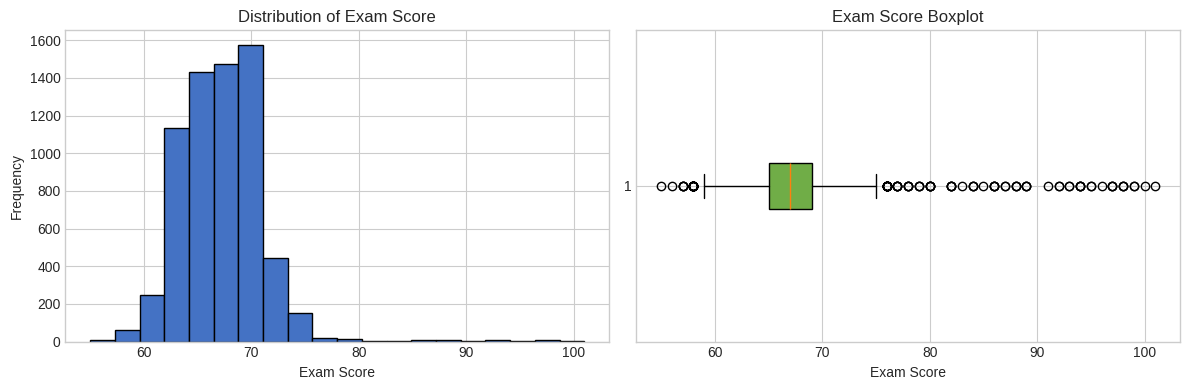

In [9]:
display(df["Exam_Score"].describe().to_frame())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    df["Exam_Score"],
    bins=20,
    color="#4472C4",
    edgecolor="black"
)
axes[0].set_title("Distribution of Exam Score")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Frequency")

axes[1].boxplot(
    df["Exam_Score"],
    vert=False,
    patch_artist=True,
    boxprops={"facecolor": "#70AD47"}
)
axes[1].set_title("Exam Score Boxplot")
axes[1].set_xlabel("Exam Score")

plt.tight_layout()
plt.show()

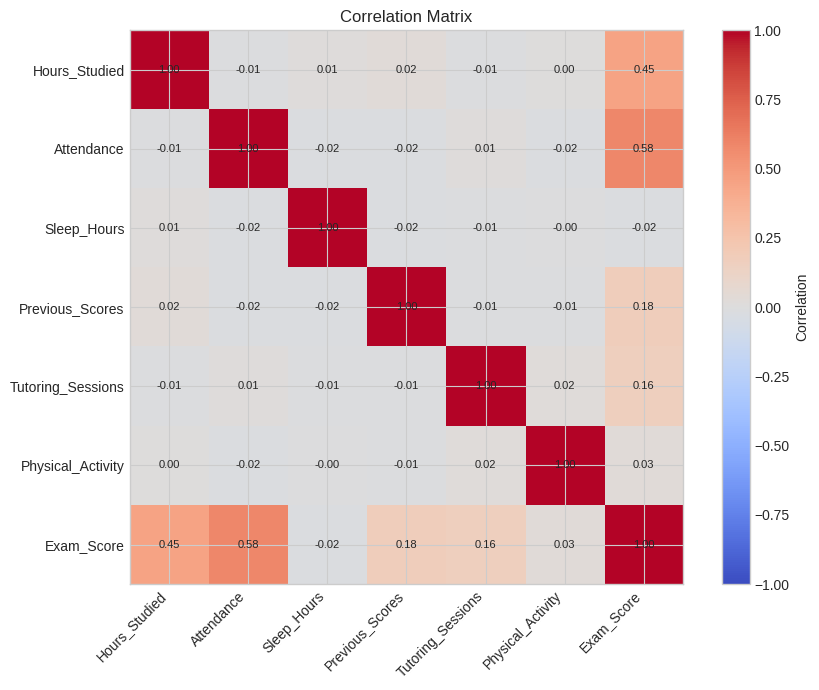

In [10]:
numeric_data = df.select_dtypes(include=np.number)
correlation = numeric_data.corr()

fig, ax = plt.subplots(figsize=(9, 7))

image = ax.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.columns)))
ax.set_xticklabels(correlation.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation.columns)

for row in range(len(correlation.columns)):
    for column in range(len(correlation.columns)):
        ax.text(
            column,
            row,
            f"{correlation.iloc[row, column]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

fig.colorbar(image, ax=ax, label="Correlation")
ax.set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

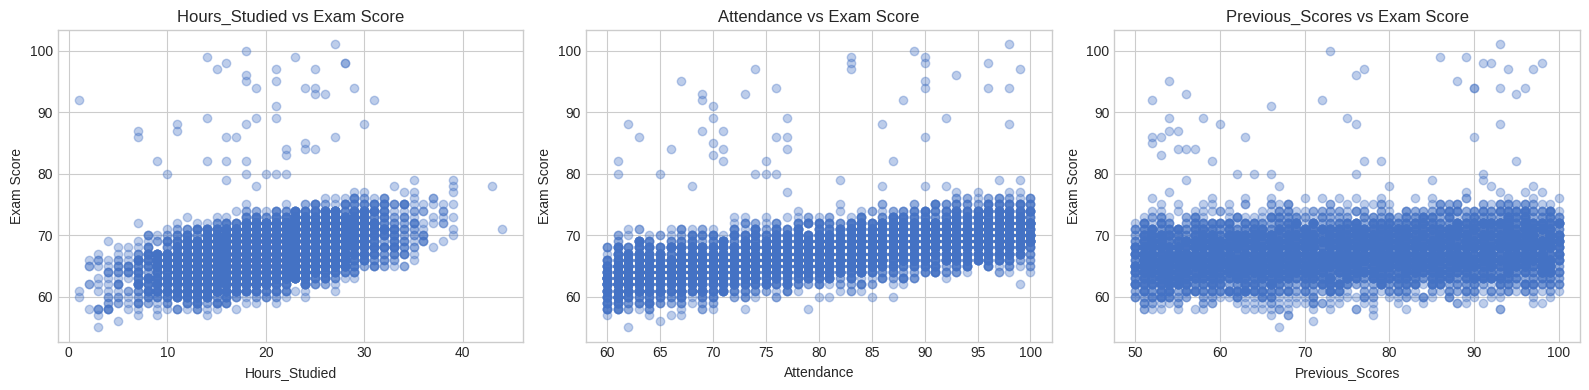

In [11]:
scatter_columns = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores"
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for axis, column in zip(axes, scatter_columns):
    axis.scatter(
        df[column],
        df["Exam_Score"],
        alpha=0.35,
        color="#4472C4"
    )
    axis.set_title(f"{column} vs Exam Score")
    axis.set_xlabel(column)
    axis.set_ylabel("Exam Score")

plt.tight_layout()
plt.show()

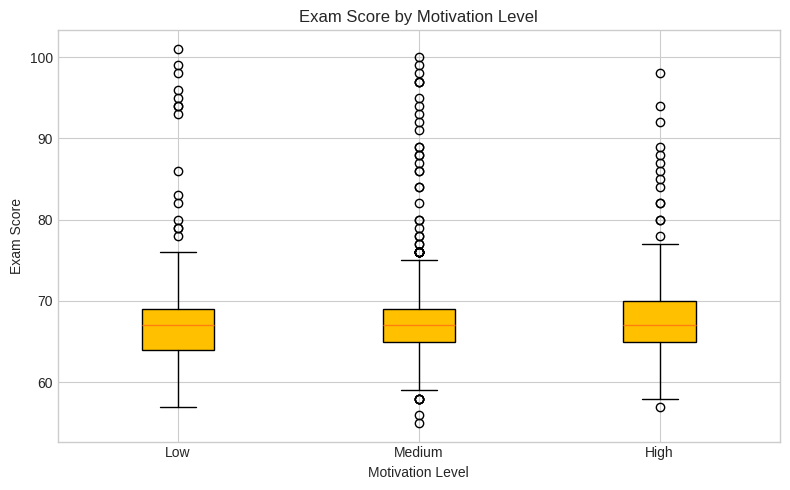

In [12]:
motivation_order = ["Low", "Medium", "High"]

motivation_data = [
    df.loc[
        df["Motivation_Level"] == level,
        "Exam_Score"
    ].dropna()
    for level in motivation_order
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    motivation_data,
    tick_labels=motivation_order,
    patch_artist=True,
    boxprops={"facecolor": "#FFC000"}
)

plt.title("Exam Score by Motivation Level")
plt.xlabel("Motivation Level")
plt.ylabel("Exam Score")
plt.tight_layout()
plt.show()

## Selección de variables

Se utilizarán todas las variables predictoras disponibles, excepto **Exam_Score**.

Las variables numéricas permiten representar aspectos como las horas de estudio, la asistencia, los resultados anteriores, las sesiones de tutoría, el sueño y la actividad física.

Las variables categóricas representan aspectos personales, familiares y escolares que también podrían contribuir a explicar el desempeño. No se identificaron columnas de identificación ni variables creadas después de obtener el puntaje que deban excluirse.

In [13]:
X = df.drop(columns="Exam_Score").copy()
y = df["Exam_Score"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("training rows:", len(X_train))
print("test rows:", len(X_test))
print("training percentage:", round(len(X_train) / len(X) * 100, 2))
print("test percentage:", round(len(X_test) / len(X) * 100, 2))

training rows: 5285
test rows: 1322
training percentage: 79.99
test percentage: 20.01


## División de los datos

Se utilizará el 80 % de los registros para entrenamiento y el 20 % para prueba.

El conjunto de entrenamiento se utiliza para ajustar los modelos. El conjunto de prueba se mantiene separado para evaluar el desempeño con observaciones que el modelo no utilizó durante su entrenamiento.

Se establece la semilla **random_state = 42** para conservar la misma división cada vez que se ejecute el notebook. Esto permite reproducir y comparar los resultados.

In [14]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

ordinal_categories = {
    "Parental_Involvement": ["Low", "Medium", "High"],
    "Access_to_Resources": ["Low", "Medium", "High"],
    "Motivation_Level": ["Low", "Medium", "High"],
    "Family_Income": ["Low", "Medium", "High"],
    "Teacher_Quality": ["Low", "Medium", "High"],
    "Peer_Influence": ["Negative", "Neutral", "Positive"],
    "Parental_Education_Level": ["High School", "College", "Postgraduate"],
    "Distance_from_Home": ["Near", "Moderate", "Far"]
}

ordinal_features = [
    column
    for column in ordinal_categories
    if column in X.columns
]

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

nominal_features = [
    column
    for column in categorical_features
    if column not in ordinal_features
]

print("numeric variables:", numeric_features)
print("ordinal variables:", ordinal_features)
print("nominal variables:", nominal_features)

numeric variables: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
ordinal variables: ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Teacher_Quality', 'Peer_Influence', 'Parental_Education_Level', 'Distance_from_Home']
nominal variables: ['Extracurricular_Activities', 'Internet_Access', 'School_Type', 'Learning_Disabilities', 'Gender']


In [15]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OrdinalEncoder(
            categories=[
                ordinal_categories[column]
                for column in ordinal_features
            ],
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    ),
    ("scaler", StandardScaler())
])

nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("ordinal", ordinal_pipeline, ordinal_features),
    ("nominal", nominal_pipeline, nominal_features)
])

print("preprocessing pipeline created")

preprocessing pipeline created


## Modelos

Se compararán los siguientes modelos:

1. **Línea base:** siempre predice la media de los puntajes del conjunto de entrenamiento.
2. **Regresión lineal:** estima el puntaje mediante una combinación lineal de las variables.
3. **Ridge:** es una regresión lineal con regularización, la cual controla coeficientes excesivamente grandes y puede reducir el sobreajuste.

Todos los modelos utilizan la misma división de entrenamiento y prueba.

In [16]:
models = {
    "Línea base": Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", DummyRegressor(strategy="mean"))
    ]),
    "Regresión lineal": Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", Ridge(alpha=1.0))
    ])
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predicted_values = model.predict(X_test)

    predictions[name] = predicted_values

    results.append({
        "Modelo": name,
        "MAE": mean_absolute_error(y_test, predicted_values),
        "RMSE": root_mean_squared_error(y_test, predicted_values),
        "R²": r2_score(y_test, predicted_values)
    })

results_df = pd.DataFrame(results)

display(results_df.round(4))

,Modelo,MAE,RMSE,R²
0,Línea base,2.8235,3.7611,-0.0007
1,Regresión lineal,0.4443,1.7994,0.7709
2,Ridge,0.4443,1.7994,0.7709


In [17]:
test_range = y_test.max() - y_test.min()

for _, row in results_df.iterrows():
    print(f"\n{row['Modelo']}")
    print(
        f"MAE: {row['MAE']:.3f} points "
        f"({row['MAE'] / test_range * 100:.2f}% of the test range)"
    )
    print(f"RMSE: {row['RMSE']:.3f} points")
    print(f"R²: {row['R²']:.4f}")


Línea base
MAE: 2.823 points (6.57% of the test range)
RMSE: 3.761 points
R²: -0.0007

Regresión lineal
MAE: 0.444 points (1.03% of the test range)
RMSE: 1.799 points
R²: 0.7709

Ridge
MAE: 0.444 points (1.03% of the test range)
RMSE: 1.799 points
R²: 0.7709


## Interpretación de las métricas

- **MAE:** representa la cantidad promedio de puntos por la que se equivoca el modelo. Por ejemplo, un MAE de 2 significa que las predicciones se alejan aproximadamente 2 puntos del puntaje real.

- **RMSE:** también representa el error en puntos, pero penaliza con mayor intensidad los errores grandes porque eleva cada diferencia al cuadrado antes de calcular el promedio.

- **R²:** indica qué proporción de la variación de **Exam_Score** es explicada por el modelo. Un valor cercano a 1 representa un mejor ajuste. Un valor cercano a 0 indica que el modelo ofrece poca mejora frente a predecir la media.

Las métricas deben interpretarse considerando la escala y el rango observado de **Exam_Score**, no únicamente afirmando que son altas o bajas.

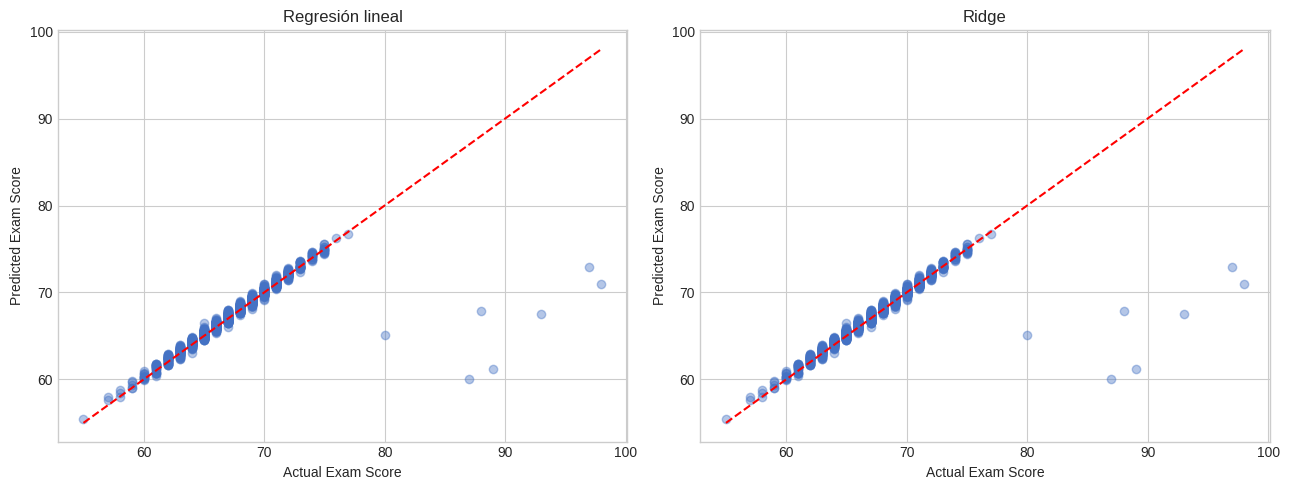

In [18]:
model_names = ["Regresión lineal", "Ridge"]

minimum_value = min(
    y_test.min(),
    predictions["Regresión lineal"].min(),
    predictions["Ridge"].min()
)

maximum_value = max(
    y_test.max(),
    predictions["Regresión lineal"].max(),
    predictions["Ridge"].max()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for axis, name in zip(axes, model_names):
    axis.scatter(
        y_test,
        predictions[name],
        alpha=0.40,
        color="#4472C4"
    )

    axis.plot(
        [minimum_value, maximum_value],
        [minimum_value, maximum_value],
        color="red",
        linestyle="--"
    )

    axis.set_title(name)
    axis.set_xlabel("Actual Exam Score")
    axis.set_ylabel("Predicted Exam Score")

plt.tight_layout()
plt.show()

best model: Ridge


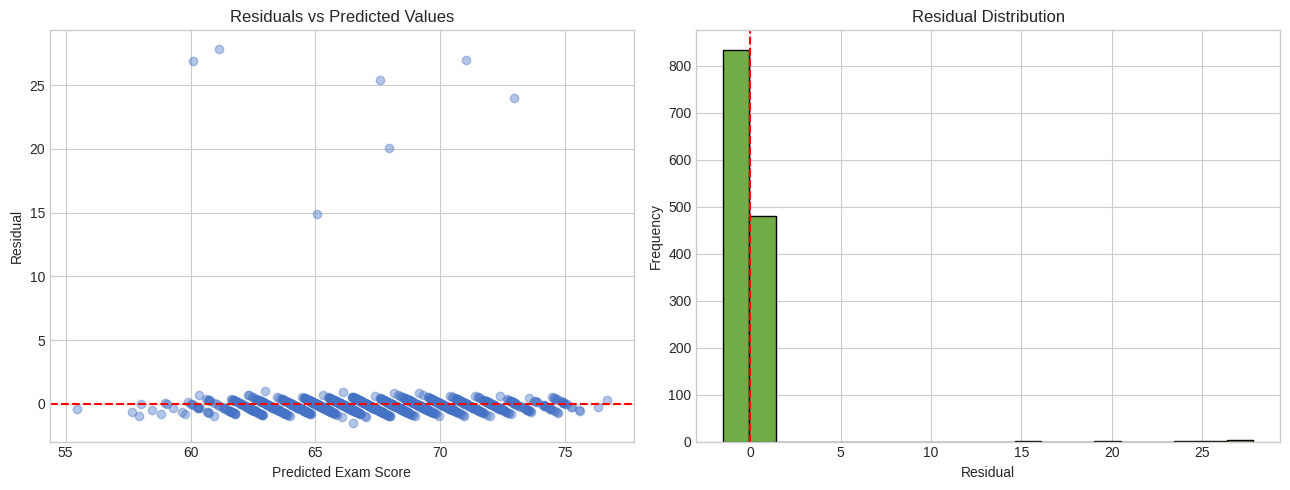

In [19]:
candidate_results = results_df[
    results_df["Modelo"].isin(["Regresión lineal", "Ridge"])
]

best_name = candidate_results.loc[
    candidate_results["RMSE"].idxmin(),
    "Modelo"
]

best_model = models[best_name]
best_predictions = predictions[best_name]
residuals = y_test.to_numpy() - best_predictions

print("best model:", best_name)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(
    best_predictions,
    residuals,
    alpha=0.40,
    color="#4472C4"
)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuals vs Predicted Values")
axes[0].set_xlabel("Predicted Exam Score")
axes[0].set_ylabel("Residual")

axes[1].hist(
    residuals,
    bins=20,
    color="#70AD47",
    edgecolor="black"
)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Análisis de residuos

Una distribución aproximadamente aleatoria alrededor de cero indica que el modelo no presenta un patrón evidente de sobreestimación o subestimación.

Los residuos alejados de cero representan observaciones en las que el modelo cometió errores grandes. La presencia de curvas, agrupaciones o cambios en la dispersión puede indicar relaciones no lineales, valores extremos o variables relevantes que no se encuentran disponibles en el dataset.

In [20]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test
error_analysis["Predicted"] = best_predictions
error_analysis["Absolute_Error"] = np.abs(
    error_analysis["Actual"] - error_analysis["Predicted"]
)

largest_errors = error_analysis.nlargest(10, "Absolute_Error")
smallest_errors = error_analysis.nsmallest(10, "Absolute_Error")

comparison_columns = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores",
    "Sleep_Hours",
    "Tutoring_Sessions",
    "Motivation_Level",
    "Parental_Involvement",
    "Access_to_Resources",
    "Actual",
    "Predicted",
    "Absolute_Error"
]

comparison_columns = [
    column
    for column in comparison_columns
    if column in error_analysis.columns
]

print("observations with the largest errors:")
display(largest_errors[comparison_columns].round(2))

print("\nobservations with the smallest errors:")
display(smallest_errors[comparison_columns].round(2))

observations with the largest errors:


,Hours_Studied,Attendance,Previous_Scores,Sleep_Hours,Tutoring_Sessions,Motivation_Level,Parental_Involvement,Access_to_Resources,Actual,Predicted,Absolute_Error
217,19,70,54,7,0,High,Medium,Low,89,61.15,27.85
4192,28,90,91,9,0,Medium,Low,Medium,98,71.02,26.98
2687,11,71,55,8,1,Medium,Low,Medium,87,60.08,26.92
4531,26,69,95,7,0,Low,High,High,93,67.58,25.42
5966,25,99,77,7,0,Medium,Medium,Medium,97,72.96,24.04
2513,18,86,60,8,2,Medium,High,Medium,88,67.93,20.07
5989,18,61,91,6,3,High,Medium,Low,80,65.08,14.92
5725,13,73,93,8,0,Medium,Medium,High,65,66.51,1.51
2118,5,89,76,4,2,High,Medium,Medium,65,66.06,1.06
1375,19,69,67,6,4,Medium,Medium,Medium,66,67.03,1.03



observations with the smallest errors:


,Hours_Studied,Attendance,Previous_Scores,Sleep_Hours,Tutoring_Sessions,Motivation_Level,Parental_Involvement,Access_to_Resources,Actual,Predicted,Absolute_Error
1954,16,96,97,9,0,Medium,High,Medium,72,72.0,0.0
2902,17,82,65,7,1,Medium,High,Medium,68,68.0,0.0
2388,25,92,72,5,1,Medium,Low,High,71,71.0,0.0
4722,20,64,95,4,4,Medium,High,Low,66,66.0,0.0
2157,18,95,85,8,2,Low,High,High,73,73.0,0.0
3206,15,81,68,5,0,Low,High,Medium,65,65.0,0.0
4553,14,90,51,7,1,Medium,Medium,Medium,66,66.0,0.0
5677,28,73,96,6,1,Medium,Medium,High,70,70.0,0.0
1886,15,85,89,7,0,High,Low,Medium,66,66.0,0.0
964,19,63,56,7,2,Medium,Medium,High,64,64.0,0.0


In [21]:
numeric_comparison = pd.DataFrame({
    "Largest errors": largest_errors[numeric_features].mean(),
    "Most accurate": smallest_errors[numeric_features].mean()
})

numeric_comparison["Difference"] = (
    numeric_comparison["Largest errors"]
    - numeric_comparison["Most accurate"]
).abs()

display(
    numeric_comparison
    .sort_values("Difference", ascending=False)
    .round(2)
)

training_standard_deviation = (
    X_train[numeric_features]
    .std()
    .replace(0, np.nan)
)

standardized_difference = (
    numeric_comparison["Difference"]
    / training_standard_deviation
).sort_values(ascending=False)

different_features = standardized_difference.head(3).index.tolist()

print(
    "numeric variables with the largest differences between groups:",
    ", ".join(different_features)
)

if largest_errors["Actual"].mean() > smallest_errors["Actual"].mean():
    print(
        "the largest errors are concentrated around higher actual scores."
    )
else:
    print(
        "the largest errors are concentrated around lower actual scores."
    )

,Largest errors,Most accurate,Difference
Attendance,77.7,82.1,4.4
Previous_Scores,75.9,77.4,1.5
Physical_Activity,2.7,3.5,0.8
Hours_Studied,18.2,18.7,0.5
Sleep_Hours,7.0,6.5,0.5
Tutoring_Sessions,1.2,1.2,0.0


numeric variables with the largest differences between groups: Physical_Activity, Attendance, Sleep_Hours
the largest errors are concentrated around higher actual scores.


## Comparación de errores

La tabla anterior permite comparar las características promedio de las observaciones con errores altos y de los casos predichos con mayor precisión.

Las variables señaladas por el análisis presentan las diferencias más claras entre ambos grupos. Sin embargo, esto no demuestra que sean la causa directa de los errores.

Los errores grandes pueden corresponder a combinaciones poco frecuentes de características, valores extremos, relaciones no lineales o factores que no están incluidos en el dataset. También pueden indicar que un modelo lineal no captura completamente algunos comportamientos del desempeño estudiantil.

,Variable,Importance
1,Attendance,1.9122
0,Hours_Studied,1.3041
3,Access_to_Resources,0.2478
6,Previous_Scores,0.2447
2,Parental_Involvement,0.2440
9,Tutoring_Sessions,0.1872
16,Parental_Education_Level,0.0858
10,Family_Income,0.0815
7,Motivation_Level,0.0794
13,Peer_Influence,0.0767


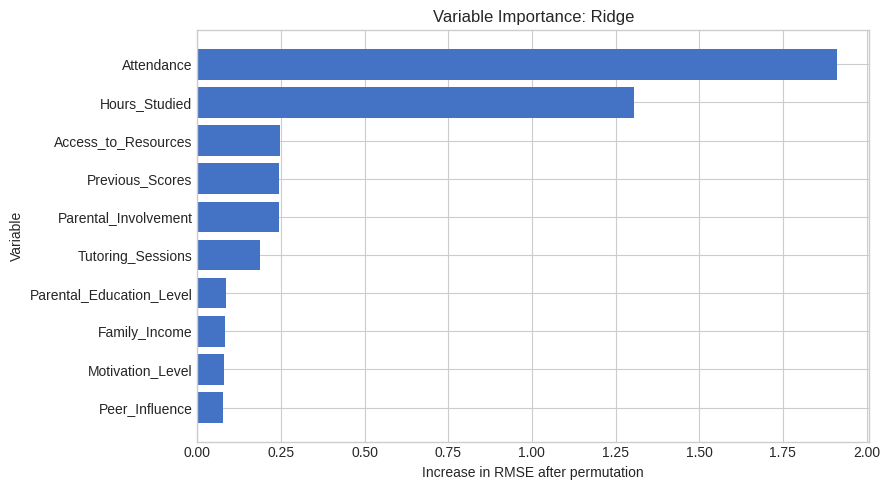

In [22]:
importance_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Variable": X.columns,
    "Importance": importance_result.importances_mean
}).sort_values("Importance", ascending=False)

display(importance_df.head(10).round(4))

top_importance = importance_df.head(10).sort_values("Importance")

plt.figure(figsize=(9, 5))

plt.barh(
    top_importance["Variable"],
    top_importance["Importance"],
    color="#4472C4"
)

plt.title(f"Variable Importance: {best_name}")
plt.xlabel("Increase in RMSE after permutation")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [23]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_rmse = -cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

single_split_rmse = candidate_results.loc[
    candidate_results["Modelo"] == best_name,
    "RMSE"
].iloc[0]

cv_results_df = pd.DataFrame({
    "Fold": range(1, 6),
    "RMSE": cv_rmse
})

display(cv_results_df.round(4))

print("single split RMSE:", round(single_split_rmse, 4))
print("cross-validation mean RMSE:", round(cv_rmse.mean(), 4))
print("cross-validation standard deviation:", round(cv_rmse.std(), 4))

,Fold,RMSE
0,1,2.0508
1,2,2.1365
2,3,1.7711
3,4,2.3510
4,5,2.1245


single split RMSE: 1.7994
cross-validation mean RMSE: 2.0868
cross-validation standard deviation: 0.1869


## Interpretación de la validación cruzada

La evaluación mediante una sola división puede variar dependiendo de qué estudiantes sean asignados al entrenamiento y a la prueba.

La validación cruzada divide el conjunto de entrenamiento en cinco partes. El modelo se entrena cinco veces, utilizando una parte diferente para validación en cada repetición.

La media representa el desempeño general del modelo y la desviación estándar muestra cuánto cambia el resultado entre las particiones. Una desviación estándar pequeña indica un comportamiento más estable.

In [24]:
baseline_row = results_df[
    results_df["Modelo"] == "Línea base"
].iloc[0]

best_row = results_df[
    results_df["Modelo"] == best_name
].iloc[0]

rmse_improvement = (
    (baseline_row["RMSE"] - best_row["RMSE"])
    / baseline_row["RMSE"]
    * 100
)

important_variables = ", ".join(
    importance_df.head(5)["Variable"].tolist()
)

print("CONCLUSION")
print()
print(f"The best model was {best_name}.")
print(f"Its MAE was {best_row['MAE']:.3f} exam points.")
print(f"Its RMSE was {best_row['RMSE']:.3f} exam points.")
print(f"Its R² was {best_row['R²']:.4f}.")
print(
    f"It reduced RMSE by {rmse_improvement:.2f}% "
    "compared with the baseline."
)
print()
print(
    "The variables with the greatest predictive importance were: "
    f"{important_variables}."
)
print()
print(
    f"Five-fold cross-validation produced a mean RMSE of "
    f"{cv_rmse.mean():.3f} with a standard deviation of "
    f"{cv_rmse.std():.3f}."
)
print()
print(
    "The model is useful as a first predictive approximation because "
    "it improves on a constant prediction. However, it should not yet "
    "be used as the only basis for academic decisions."
)
print()
print(
    "The analysis is limited by the available variables, possible "
    "extreme observations and relationships that may not be completely "
    "linear. A future version could evaluate nonlinear models, tune "
    "hyperparameters and validate the results with additional student data."
)

CONCLUSION

The best model was Ridge.
Its MAE was 0.444 exam points.
Its RMSE was 1.799 exam points.
Its R² was 0.7709.
It reduced RMSE by 52.16% compared with the baseline.

The variables with the greatest predictive importance were: Attendance, Hours_Studied, Access_to_Resources, Previous_Scores, Parental_Involvement.

Five-fold cross-validation produced a mean RMSE of 2.087 with a standard deviation of 0.187.

The model is useful as a first predictive approximation because it improves on a constant prediction. However, it should not yet be used as the only basis for academic decisions.

The analysis is limited by the available variables, possible extreme observations and relationships that may not be completely linear. A future version could evaluate nonlinear models, tune hyperparameters and validate the results with additional student data.


## Conclusión

La celda anterior genera la conclusión utilizando los resultados reales obtenidos durante la ejecución. La selección del mejor modelo se realiza con base en el menor RMSE entre la regresión lineal y Ridge.

El modelo seleccionado se compara con la línea base, se identifican las variables de mayor importancia y se evalúa su estabilidad mediante validación cruzada de cinco particiones.

Aunque el modelo puede considerarse suficiente como primera aproximación, requiere mayor validación antes de utilizarse para apoyar decisiones académicas. Los resultados representan asociaciones predictivas y no demuestran relaciones de causa y efecto.

In [25]:
processed_file = "StudentPerformanceFactors_processed.csv"

df.to_csv(
    processed_file,
    index=False
)

files.download(processed_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Fuentes

- Abdel-Ghany, M. (2025). *Student Performance Factors Dataset*. Kaggle.  
  https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset

- Scikit-learn. *Pipeline*.  
  https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html

- Scikit-learn. *ColumnTransformer*.  
  https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html

- Scikit-learn. *Regression metrics*.  
  https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics